#### 연습 문제
1. 5월 19일 날짜에 작업했던 하이닉스 주식 데이터를 로드하는 방법을 이용
    - 야후파이낸스에서 일별 데이터를 로드하는 기간은 2000년부터 가능

2. opendartreader 라이브러리를 이용해서 영업이익 데이터를 로드
    - env 활용해서 api_key 데이터 공유 금지
    - Dart 전자공시 2015년부터 전자공시 필수화(15년 이후의 공시 데이터를 서치 가능)
    - 15년 이전의 데이터들은 웹크롤링을 이용하여 노가다

3. 주가의 데이터는 15년부터 불러오고 영업이익 데이터도 15년부터 데이터를 로드하여 데이터를 결합
    - 영업 이익이 존재하지 않는 데이터들은 제거(결측치 제거)

4. 이동 평균선(20일)을 생성하고 이격도 컬럼을 생성

5. 종가, 거래량, 이격도, 영업이익 데이터를 이용하여 LSTM 모델에 학습 데이터로 이용

6. train, test 비율을 85:15로 생성하여 데이터 예측 모델을 생성

7. epoch = 20, window = 60, 학습 배치 갯수 = 64, 학습 배치 갯수 = 32, 검증 배치 갯수 = 32, lr = 0.001

In [36]:
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import MinMaxScaler
import yfinance as yf
import OpenDartReader
from datetime import datetime
import os
from dotenv import load_dotenv
import time
import torch.nn as nn

In [3]:
hynix = yf.Ticker('000660.KS')
# df = hynix.history(period='12y')
df = hynix.history(start = '2015-01-01')
df.head()

,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
2015-01-02 00:00:00+09:00,41592.270902,41982.605039,41332.048143,41418.789062,1155944,0.0,0.0
2015-01-05 00:00:00+09:00,41679.010542,41982.603751,41201.935500,41332.046875,1409146,0.0,0.0
2015-01-06 00:00:00+09:00,40768.225164,41288.670592,40681.484260,41201.929688,1661196,0.0,0.0
2015-01-07 00:00:00+09:00,40508.001187,41288.669304,40508.001187,41115.187500,1821266,0.0,0.0
2015-01-08 00:00:00+09:00,41852.490420,43370.456394,41548.897225,43327.085938,5006675,0.0,0.0


In [4]:
df = df.loc[df.index > '2015-01-01']
df

,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
2015-01-02 00:00:00+09:00,4.159227e+04,4.198261e+04,4.133205e+04,4.141879e+04,1155944,0.0,0.0
2015-01-05 00:00:00+09:00,4.167901e+04,4.198260e+04,4.120194e+04,4.133205e+04,1409146,0.0,0.0
2015-01-06 00:00:00+09:00,4.076823e+04,4.128867e+04,4.068148e+04,4.120193e+04,1661196,0.0,0.0
2015-01-07 00:00:00+09:00,4.050800e+04,4.128867e+04,4.050800e+04,4.111519e+04,1821266,0.0,0.0
2015-01-08 00:00:00+09:00,4.185249e+04,4.337046e+04,4.154890e+04,4.332709e+04,5006675,0.0,0.0
...,...,...,...,...,...,...,...
2026-05-20 00:00:00+09:00,1.743000e+06,1.778000e+06,1.690000e+06,1.745000e+06,5535123,0.0,0.0
2026-05-21 00:00:00+09:00,1.801000e+06,1.954000e+06,1.796000e+06,1.940000e+06,5096690,0.0,0.0
2026-05-22 00:00:00+09:00,1.942000e+06,1.952000e+06,1.912000e+06,1.941000e+06,3135190,0.0,0.0


In [5]:
# 종가, 거래량을 제외한 나머지 컬럼들을 제외 (특정 컬럼만 선택)
df = df[['Close','Volume']]
# 이동평균선
df['MA20'] = df['Close'].rolling(20).mean()
df.head()

,Close,Volume,MA20
Date,,,
2015-01-02 00:00:00+09:00,41418.789062,1155944,NaN
2015-01-05 00:00:00+09:00,41332.046875,1409146,NaN
2015-01-06 00:00:00+09:00,41201.929688,1661196,NaN
2015-01-07 00:00:00+09:00,41115.187500,1821266,NaN
2015-01-08 00:00:00+09:00,43327.085938,5006675,NaN


In [6]:
# .env 파일의 정보를 로드
load_dotenv()

True

In [7]:
api_key = os.getenv('api_key')

In [8]:
dart = OpenDartReader(api_key)

In [9]:
# 2015년부터 2026년까지 년도별 영업이익을 구하기 위해 연도 list 생성
current_year = datetime.now().year
years = range(2015,2027)
years

range(2015, 2027)

In [10]:
# 보고서 리스트 생성
report_codes = ['11013','11012','11014','11011']
dart_data_list = []

In [11]:
for year in years:
    for code in report_codes:
        try :
            report = dart.finstate('000660', year, code)
            if report is not None:
                op_profit = report[ (report['fs_div'] == 'CFS')  & ( report['account_nm'] == '영업이익' ) ]
                if not op_profit.empty:
                    val = int(
                            op_profit['thstrm_amount'].values[0].replace(',', '')
                        )
                    # code 11013 -> 1분기 보고서
                    if code == '11013' : d = f"{year}-05-15"
                    elif code == '11012' : d = f"{year}-08-14"
                    elif code == '11014' : d = f"{year}-11-14"
                    else : d = f"{year+1}-03-31"

                    report_date = pd.to_datetime(d)
                    if report_date <= datetime.now():
                        dart_data_list.append({'Date' : report_date, 'Operation_Profit' : val})
        except: continue
dart_data_list

{'status': '013', 'message': '조회된 데이타가 없습니다.'}

{'status': '013', 'message': '조회된 데이타가 없습니다.'}

{'status': '013', 'message': '조회된 데이타가 없습니다.'}

{'status': '013', 'message': '조회된 데이타가 없습니다.'}

{'status': '013', 'message': '조회된 데이타가 없습니다.'}

{'status': '013', 'message': '조회된 데이타가 없습니다.'}



[{'Date': Timestamp('2016-03-31 00:00:00'), 'Operation_Profit': 5336100000000},
 {'Date': Timestamp('2016-05-15 00:00:00'), 'Operation_Profit': 561798000000},
 {'Date': Timestamp('2016-08-14 00:00:00'), 'Operation_Profit': 452853000000},
 {'Date': Timestamp('2016-11-14 00:00:00'), 'Operation_Profit': 725956000000},
 {'Date': Timestamp('2017-03-31 00:00:00'), 'Operation_Profit': 3276746000000},
 {'Date': Timestamp('2017-05-15 00:00:00'), 'Operation_Profit': 2467599000000},
 {'Date': Timestamp('2017-08-14 00:00:00'), 'Operation_Profit': 3050700000000},
 {'Date': Timestamp('2017-11-14 00:00:00'), 'Operation_Profit': 3737193000000},
 {'Date': Timestamp('2018-03-31 00:00:00'),
  'Operation_Profit': 13721326000000},
 {'Date': Timestamp('2018-05-15 00:00:00'), 'Operation_Profit': 4367338000000},
 {'Date': Timestamp('2018-08-14 00:00:00'), 'Operation_Profit': 5573918000000},
 {'Date': Timestamp('2018-11-14 00:00:00'), 'Operation_Profit': 6472420000000},
 {'Date': Timestamp('2019-03-31 00:00:00

In [13]:
# 시간, 영업이익 데이터를 데이터프레임 생성
dart_df = pd.DataFrame(dart_data_list)
dart_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 42 entries, 0 to 41
Data columns (total 2 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Date              42 non-null     datetime64[us]
 1   Operation_Profit  42 non-null     int64         
dtypes: datetime64[us](1), int64(1)
memory usage: 804.0 bytes


In [18]:
display(df.head(1))
display(dart_df.head(1))

,Close,Volume,MA20
Date,,,
2015-01-02,41418.789062,1155944,NaN


,Date,Operation_Profit
0,2016-03-31,5336100000000


In [16]:
# 결합 전 df의 timezone을 제거
df.index = df.index.tz_localize(None)

In [24]:
# 💡 해결책: 판다스 문법 버그를 피하기 위해 강제로 'datetime64[ns]' 타입으로 못박아버립니다.

# 1. df 인덱스를 나노초 단위 데이터타입으로 강제 변환
df.index = pd.to_datetime(df.index).astype('datetime64[ns]')

# 2. dart_df['Date'] 컬럼도 똑같은 나노초 단위 데이터타입으로 강제 변환
dart_df['Date'] = pd.to_datetime(dart_df['Date']).astype('datetime64[ns]')

# 3. merge_asof 정렬 필수 조건 만족시키기
df = df.sort_index()
dart_df = dart_df.sort_values('Date')

# 4. 병합 실행
df = pd.merge_asof(df, dart_df, left_index=True, right_on='Date', direction='backward')

In [25]:
# 결측치가 포함되어있는 인덱스는 제거
df.dropna(inplace = True)

In [26]:
df.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 2485 entries, 2016-03-31 to 2026-05-27
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Close             2485 non-null   float64       
 1   Volume            2485 non-null   int64         
 2   MA20              2485 non-null   float64       
 3   Date              2485 non-null   datetime64[ns]
 4   Operation_Profit  2485 non-null   float64       
dtypes: datetime64[ns](1), float64(3), int64(1)
memory usage: 116.5 KB


In [27]:
df.head(3)

,Close,Volume,MA20,Date,Operation_Profit
Date,,,,,
2016-03-31,24819.177734,4336581,26311.408301,2016-03-31,5.336100e+12
2016-04-01,24863.255859,2991431,26148.298145,2016-04-01,5.336100e+12
2016-04-04,24598.751953,2823088,25971.962793,2016-04-04,5.336100e+12


In [28]:
# 이격도
df['Dist_MA20'] = (df['Close'] - df['MA20'])/df['MA20']

In [29]:
x = df[['Close','Volume','Operation_Profit','Dist_MA20']].values
y = df[['Close']].values

In [30]:
split_idx = int(len(df) * 0.85)
X_train, X_test = x[:split_idx], x[split_idx:]
y_train, y_test = y[:split_idx], y[split_idx:]


In [31]:
# 스케일링 작업
x_scaler = MinMaxScaler().fit(X_train)
y_scaler = MinMaxScaler().fit(y_train)

x_train_sc = x_scaler.transform(X_train)
x_test_sc = x_scaler.transform(X_test)
y_train_sc = y_scaler.transform(y_train)
y_test_sc = y_scaler.transform(y_test)

In [32]:
# 딥러닝 초기 값들을 미리 지정

window = 60
epochs = 20
train_batch = 32
test_batch = 32
lr = 0.001
hidden_cnt = 64
head_type = 'c'


In [33]:
class windowDS(Dataset):
    def __init__(self, _x, _y, _window):
        self.x = _x
        self.y = _y
        self.window = _window
        self.n = len(_x) - _window

    def __len__(self):
        return self.n
    
    def __getitem__(self, idx):
        x = self.x[idx : idx + self.window]
        y = self.y[idx + self.window]

        x_tensor = torch.from_numpy(x)  # 얕은 복사
        y_tensor = torch.tensor(y)  # 깊은 복사

        return x_tensor, y_tensor

In [34]:
# DS 생성
train_ds = windowDS(x_train_sc, y_train_sc, window)
test_ds = windowDS(x_test_sc, y_test_sc, window)

In [35]:
# DataLoader 생성
train_dl = DataLoader(train_ds, shuffle = True, drop_last = True, batch_size = train_batch)
test_dl = DataLoader(test_ds, shuffle=False, drop_last = False, batch_size = test_batch)

In [50]:
class LSTMModel(nn.Module):
    def __init__(
            self,
            input_size,
            hidden_size,
            num_layers = 1,
            dropout = 0.0,
            bidirectional = False,
            head_type = 'h'
    ):
        super(LSTMModel, self).__init__()
        self.lstm = nn.LSTM(
            input_size = input_size,
            hidden_size = hidden_size,
            num_layers = num_layers,
            dropout = dropout,
            bidirectional = bidirectional,
            batch_first = True
        )

        hidden_size = int(hidden_size)
        if head_type in ['h','c']:
            pass
        elif head_type == 'h_c':
            hidden_size *= 2
        else:
            print('head_type error')
        
        self.model = nn.Linear(hidden_size, 1)
        self.head_type = head_type
    
    def forward(self, x):
        out, (h_n, c_n) = self.lstm(x)
        h_last = h_n[-1]
        c_last = c_n[-1]

        if self.head_type == 'h':
            feat = h_last
        elif self.head_type == 'c':
            feat = c_last
        elif self.head_type == 'h_c':
            feat = torch.cat([h_last,c_last], dim = -1 )
            
        return self.model(feat)

In [51]:
model = LSTMModel(input_size = x.shape[1], hidden_size = hidden_cnt, head_type = head_type)

In [52]:
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr = lr)

In [49]:
# 검증 데이터를 이용하여 mse 값을 구하는 함수
@torch.no_grad()
def evaluate_mse(dl):
    model.eval()
    total_loss, total_n = 0.0, 0
    for x,y in dl:
        x = x.float()
        y = y.float()
        pred = model(x)
        loss = criterion(pred, y)
        total_loss = loss.item() * y.size(0)
        total_n += y.size(0)
    return total_loss / max(total_n, 1)

In [53]:
for epoch in range(epochs):
    model.train()
    total_loss, total_n = 0.0, 0
    for x,y in train_dl:
        x = x.float()
        y = y.float()

        pred = model(x)
        loss = criterion(pred, y)
        optimizer.zero_grad()
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        total_loss += loss.item() * y.size(0)
        total_n += y.size(0)
    
    train_loss = total_loss / max(total_n, 1)
    test_loss = evaluate_mse(test_dl)

    print(f'Epoch : {epoch}, train_mse : {train_loss}, test_loss : {test_loss}')

Epoch : 0, train_mse : 0.021089034400574747, test_loss : 0.22605670907626899
Epoch : 1, train_mse : 0.0011788675833486195, test_loss : 0.11983053943219657
Epoch : 2, train_mse : 0.0003240323601971795, test_loss : 0.2959912767806373
Epoch : 3, train_mse : 0.00027671754094171774, test_loss : 0.31011654926945986
Epoch : 4, train_mse : 0.00026482014743578475, test_loss : 0.3339859243399038
Epoch : 5, train_mse : 0.00027054021836647735, test_loss : 0.3536824601145979
Epoch : 6, train_mse : 0.00024916760798987525, test_loss : 0.35060507040054273
Epoch : 7, train_mse : 0.0002678498865407164, test_loss : 0.37772746893544545
Epoch : 8, train_mse : 0.00024529444499421516, test_loss : 0.36559177282900096
Epoch : 9, train_mse : 0.0003011808663586635, test_loss : 0.3805211176887488
Epoch : 10, train_mse : 0.00023209794693457297, test_loss : 0.3914017646838301
Epoch : 11, train_mse : 0.00025035073826984444, test_loss : 0.370180302153761
Epoch : 12, train_mse : 0.0002281421252519067, test_loss : 0.37

In [54]:
model.eval()

preds = []
trues = []

with torch.no_grad():
    for x,y in test_dl:
        x = x.float()
        pred = model(x)
        preds.append(pred)
        trues.append(y)

preds = torch.cat(preds, dim=0).numpy()
trues = torch.cat(trues, dim=0).numpy()

pred_origin = y_scaler.inverse_transform(preds).squeeze()
true_origin = y_scaler.inverse_transform(trues).squeeze()

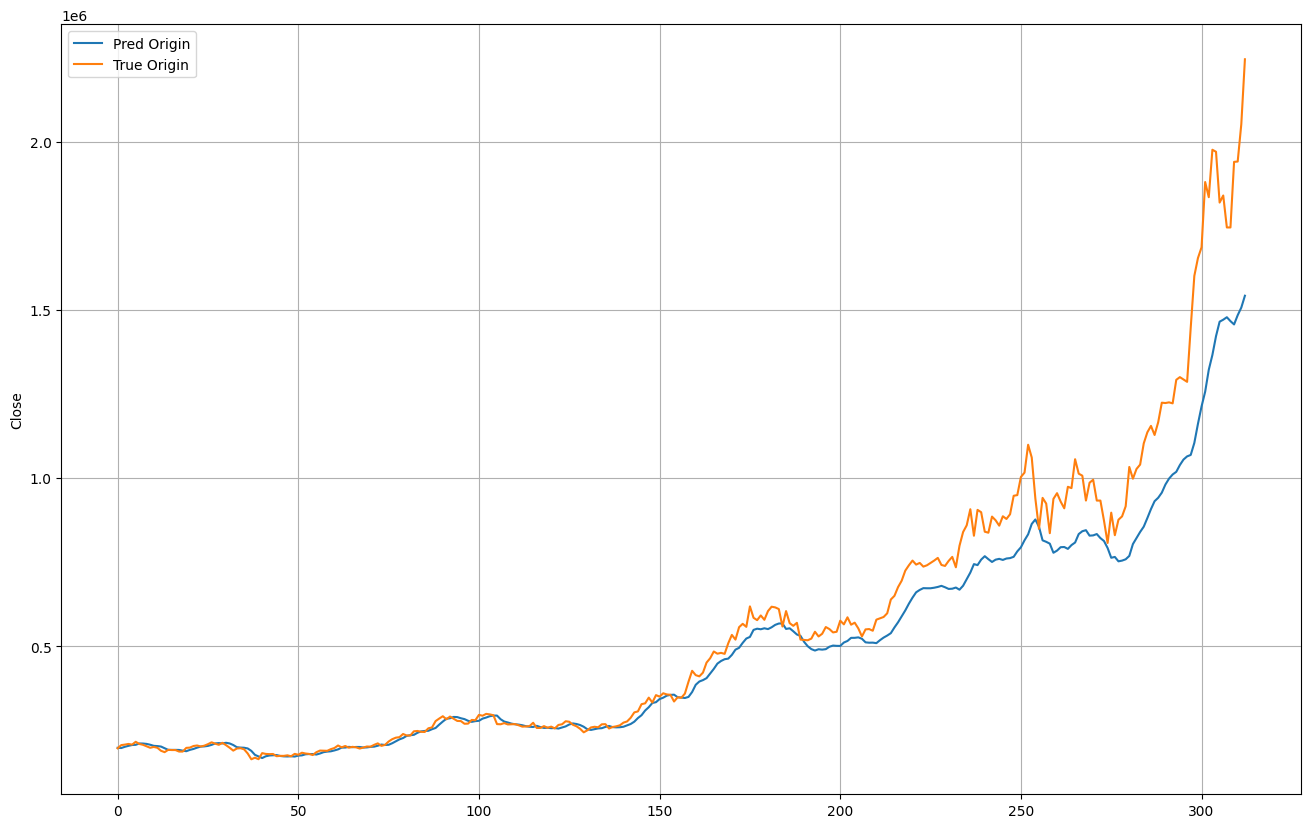

In [56]:
plt.figure(figsize=(16,10))
plt.plot(pred_origin, label = 'Pred Origin')
plt.plot(true_origin, label = 'True Origin')

plt.legend()
plt.grid()
plt.ylabel('Close')
# 그림으로 저장
plt.savefig('하이닉스.png')
plt.show()